# Problem 3: Newton's and Broyden's Methods
- Write code that implements Newton’s method for a generic multivariate nonlinear system
F(x) = 0. It can either require the user to supply the Jacobian, or it can calculate it
automatically using automatic differentiation. Turn in your source code; you can use any
language but we recommend Python
- Show that you can use a third-party library that implements Broyden’s method. You do
not need to code Broyden’s method yourself! In Python, we recommend
scipy.optimize.root(..., method=’broyden1’,...) (which is Broyden’s “good method”,
similar to what our book has but with a few extra goodies). In Matlab, you can use a third
party implementation from the File Exchange, but make sure to vet the implementation.
Turn in your source code that shows you using the software
- For both the Newton and Broyden implementations, demonstrate that they work by solving
the GNSS Equation (2) in dimension n = 3 with a starting guess of x0 = [−.1, −.1, −.1].
- Again solve Equation (2) with both methods, but do this three times, once each for n =
1000, n = 2000 and n = 4000, to a tolerance of 10−9 (i.e., a condition like ‖xk+1 − xk‖2 ≤
10−9)1. Make two plots, one plot showing the number of iterations required as a function
of n (both methods on the same plot), and the other plot showing the time per iteration
as a function of n (again, both methods on the same plot).
- Discuss the results you found above. For this particular problem, which method do you
recommend? Bonus: Do you think it depends on your implementation? Profile your
Newton method code to see what the slowest step is. If it’s not the linear system solve, then
your code is not as efficient as it could be!

Running for n=1000...
Running for n=2000...
Running for n=4000...


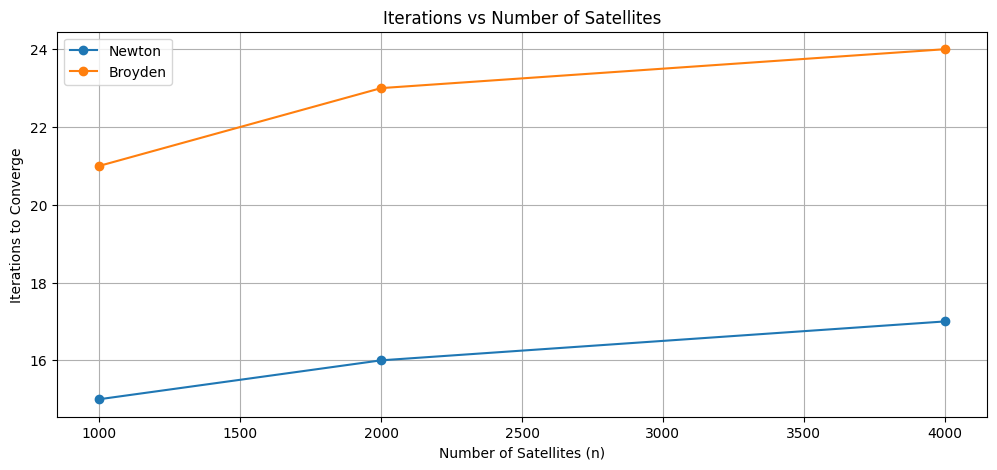

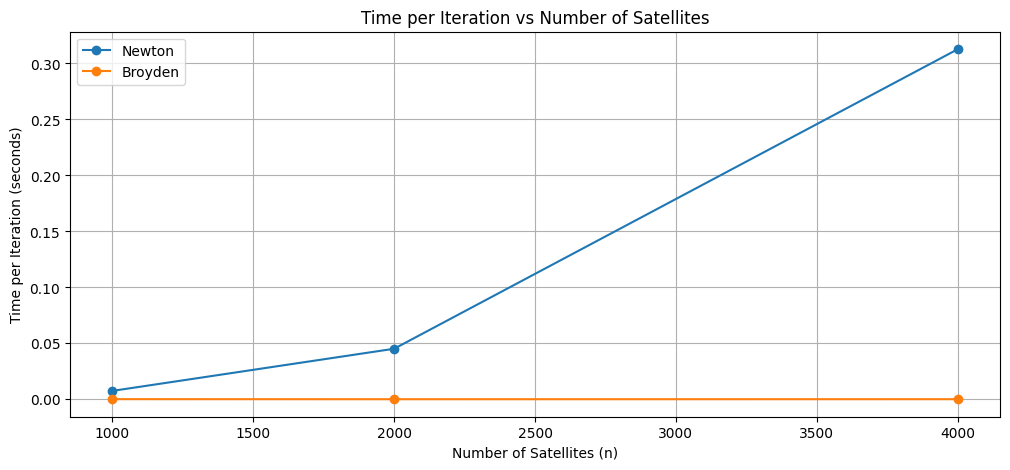

         1204 function calls (1201 primitive calls) in 0.103 seconds

   Ordered by: cumulative time
   List reduced from 109 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      5/4    0.000    0.000    0.103    0.026 /Users/n1le/Library/Python/3.14/lib/python/site-packages/IPython/core/interactiveshell.py:3665(run_code)
        4    0.000    0.000    0.103    0.026 {built-in method builtins.exec}
        1    0.000    0.000    0.102    0.102 /var/folders/40/26f5s8qj42z2mxw1gfrnh5rm0000gn/T/ipykernel_76206/3247042491.py:7(newton)
       15    0.082    0.005    0.082    0.005 /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:363(solve)
       15    0.009    0.001    0.019    0.001 /var/folders/40/26f5s8qj42z2mxw1gfrnh5rm0000gn/T/ipykernel_76206/3247042491.py:75(J)
       15    0.007    0.000    0.007    0.000 /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/sit

In [1]:
import numpy as np
import time
from scipy.optimize import root
import matplotlib.pyplot as plt

# Newton method
def newton(F, x0, J=None, tol=1e-9, max_iter=100, verbose=False):
    """ Newton solver for F(x) = 0. 
    Parameters: 
        F: function, f R^n -> R^n
        x0: initial guess
        J : Jacobian
        tol: stopping tolerance
        max_iter: max number of ites
    Returns:
        x, info dictionary
    """

    x = x0.astype(float)
    n = len(x)

    def numerical_jacobian(x):
        # compute the Jacobian matrix using finite differences
        eps = 1e-8
        J = np.zeros((n, n))
        fx = F(x)

        for i in range(n):
            dx = np.zeros(n)
            dx[i] = eps
            J[:, i] = (F(x + dx) - fx) / eps
        
        return J

    start_time = time.time()

    for k in range(max_iter):
        fx = F(x)

        if J is None:
            Jx = numerical_jacobian(x)
        else:
            Jx = J(x)

        delta = np.linalg.solve(Jx, -fx)
        x_new = x + delta

        if np.linalg.norm(delta) < tol:
            total_time = time.time() - start_time
            return x_new, {
                "iterations": k + 1,
                "time": total_time,
                "time_per_iter": total_time / (k + 1),
                "converged": True
            }

        x = x_new

    total_time = time.time() - start_time
    return x, {
        "iterations": max_iter,
        "time": total_time,
        "time_per_iter": total_time / max_iter,
        "converged": False
    }
    
# GNSS equation system
def gnss_system(n):
    # Returns F and J for the GNSS system with n satellites ( n dimensional )

    def F(x):
        norm_sq = np.dot(x, x)
        return norm_sq * np.ones(n) - 2*x 
    
    def J(x):
        # derivative: d/dx_j of (||x||^2 - 2x_i)
        # = 2x_j - 2 δ_ij
        return 2 * np.outer(np.ones(n), x) - 2 * np.eye(n)
    
    return F, J

# Broyden via SciPy
def broyden_solver(F, x0, tol=1e-9):
    start_time = time.time()

    sol = root(F, x0, method='broyden1', options={'xatol': tol})

    total_time = time.time() - start_time

    return sol.x, {
        "iterations": sol.nit,
        "time": total_time,
        "time_per_iter": total_time / max(sol.nit, 1),
        "converged": sol.success
    }

# Run experiments
def run_experiments(n_values, tol=1e-9):

    newton_iters = []
    broyden_iters = []
    newton_time_per_iter = []
    broyden_time_per_iter = []

    for n in n_values:
        print(f"Running for n={n}...")

        F, J = gnss_system(n)
        x0 = -np.ones(n)  # Initial guess

        # Newton
        _, info_newton = newton(F, x0, J=J, tol=tol)
        newton_iters.append(info_newton["iterations"])
        newton_time_per_iter.append(info_newton["time_per_iter"])

        # Broyden
        _, info_broyden = broyden_solver(F, x0, tol=tol)
        broyden_iters.append(info_broyden["iterations"])
        broyden_time_per_iter.append(info_broyden["time_per_iter"])

    return (newton_iters, broyden_iters,
            newton_time_per_iter, broyden_time_per_iter)

# Plotting
def make_plots(n_values, newton_iters, broyden_iters,
               newton_time_per_iter, broyden_time_per_iter):
     
    # Plot 1: Iterations vs n
    plt.figure(figsize=(12, 5))
    plt.plot(n_values, newton_iters, label='Newton', marker='o')
    plt.plot(n_values, broyden_iters, label='Broyden', marker='o')
    plt.xlabel('Number of Satellites (n)')
    plt.ylabel('Iterations to Converge')
    plt.legend()
    plt.title('Iterations vs Number of Satellites')
    plt.grid()
    plt.show()

    # Plot 2: Time per Iteration vs n
    plt.figure(figsize=(12, 5))
    plt.plot(n_values, newton_time_per_iter, label='Newton', marker='o')
    plt.plot(n_values, broyden_time_per_iter, label='Broyden', marker='o')
    plt.xlabel('Number of Satellites (n)')
    plt.ylabel('Time per Iteration (seconds)')
    plt.legend()
    plt.title('Time per Iteration vs Number of Satellites')
    plt.grid()
    plt.show()

# Driver
n_values = [1000, 2000, 4000]
newton_iters, broyden_iters, newton_time_per_iter, broyden_time_per_iter = run_experiments(n_values, tol=1e-12)
make_plots(n_values, newton_iters, broyden_iters, newton_time_per_iter, broyden_time_per_iter)

import cProfile
import pstats

profiler = cProfile.Profile()
profiler.enable()

F, J = gnss_system(1000)
x0 = -np.ones(1000)
newton(F, x0, J=J)

profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(10)

**Commentary**: For the runtime, profiling shows that the primary computational cost is the solution of the linear system at each iteration. The jacobian and residual evaluation are negligable in comparison. 

## Problem 4: fixed point iteration


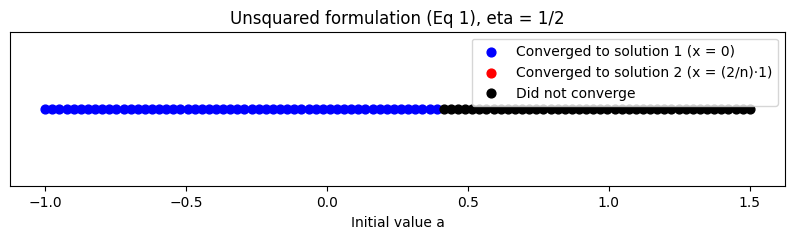

/var/folders/40/26f5s8qj42z2mxw1gfrnh5rm0000gn/T/ipykernel_76206/3922771221.py:66: RuntimeWarning: invalid value encountered in subtract
  if np.linalg.norm(x_new - x) < tol:


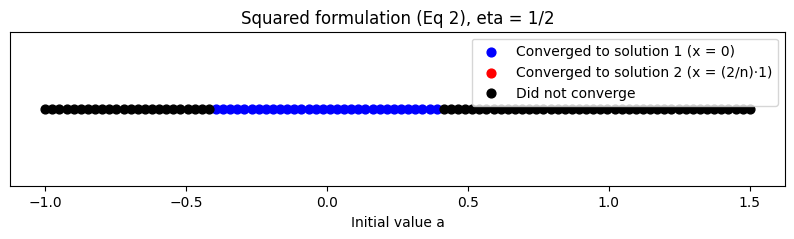

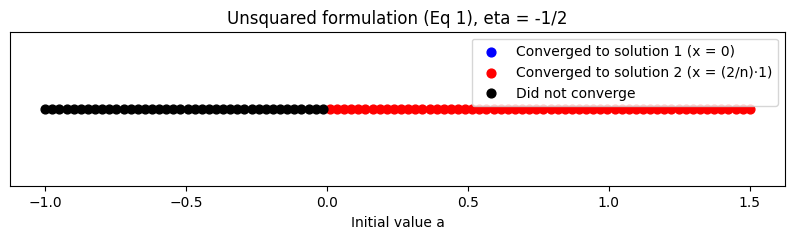

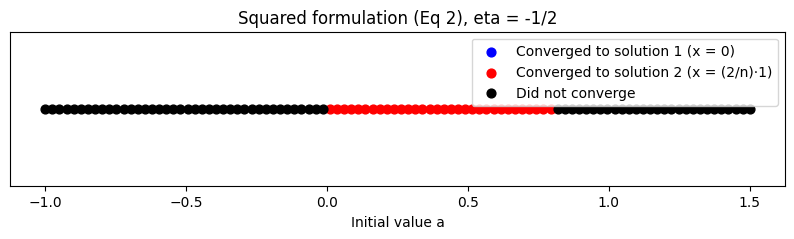

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def F1(x):
    """
    Unsquared formulation:
        ||x - e_i||_2 = 1

    Converted to F(x) = 0 form:
        F_i(x) = ||x - e_i||_2 - 1
    """
    n = len(x)
    F = np.zeros(n)

    for i in range(n):
        ei = np.zeros(n)
        ei[i] = 1.0
        F[i] = np.linalg.norm(x - ei) - 1.0

    return F


def F2(x):
    """
    Squared formulation:
        ||x - e_i||_2^2 = 1

    Converted to F(x) = 0 form:
        F_i(x) = ||x - e_i||_2^2 - 1
    """
    n = len(x)
    F = np.zeros(n)

    for i in range(n):
        ei = np.zeros(n)
        ei[i] = 1.0
        diff = x - ei
        F[i] = np.dot(diff, diff) - 1.0

    return F

def fixed_point_iteration(F, x0, eta,
                          max_iter=100,
                          tol=1e-6):
    """
    Fixed point iteration:
        x_{k+1} = x_k + eta * F(x_k)
    """

    x = x0.copy()

    for k in range(max_iter):

        x_new = x + eta * F(x)

        if np.linalg.norm(x_new - x) < tol:
            return x_new, True, k + 1

        x = x_new

    return x, False, max_iter

def get_fixed_points(n):
    """
    Returns the two known fixed points:

    solution 1: x = 0
    solution 2: x = (2/n)[1,1,...,1]
    """

    sol1 = np.zeros(n)
    sol2 = np.ones(n) * (2.0 / n)

    return sol1, sol2

def classify_solution(x, fixed_points, tol=1e-6):

    for i, p in enumerate(fixed_points):

        if np.linalg.norm(x - p) < tol:
            return i

    return -1

def run_experiment(F,
                   n=5,
                   eta=0.5,
                   a_min=-1,
                   a_max=1.5,
                   num_points=100,
                   max_iter=100,
                   tol=1e-6):

    fixed_points = get_fixed_points(n)

    a_values = np.linspace(a_min, a_max, num_points)

    results = np.zeros(num_points, dtype=int)

    for i, a in enumerate(a_values):

        x0 = np.ones(n) * a

        x_final, converged, iters = fixed_point_iteration(
            F, x0, eta, max_iter, tol
        )

        if converged:
            results[i] = classify_solution(
                x_final, fixed_points, tol
            )
        else:
            results[i] = -1

    return a_values, results


def plot_results(a_values, results, title):

    # Convert to numpy arrays
    a_values = np.array(a_values)
    results = np.array(results)

    # Masks for each outcome
    mask_sol1 = results == 0
    mask_sol2 = results == 1
    mask_div  = results == -1

    plt.figure(figsize=(10, 2))

    # Plot each separately so legend works
    plt.scatter(a_values[mask_sol1],
                np.zeros(np.sum(mask_sol1)),
                color="blue",
                s=40,
                label="Converged to solution 1 (x = 0)")

    plt.scatter(a_values[mask_sol2],
                np.zeros(np.sum(mask_sol2)),
                color="red",
                s=40,
                label="Converged to solution 2 (x = (2/n)·1)")

    plt.scatter(a_values[mask_div],
                np.zeros(np.sum(mask_div)),
                color="black",
                s=40,
                label="Did not converge")

    plt.title(title)
    plt.xlabel("Initial value a")
    plt.yticks([])

    plt.legend(loc="upper right", frameon=True)

    plt.show()

n = 5

# Part (b): eta = 1/2
eta = 0.5

a_vals1, res1 = run_experiment(F1, n=n, eta=eta)
plot_results(a_vals1, res1,
                "Unsquared formulation (Eq 1), eta = 1/2")

a_vals2, res2 = run_experiment(F2, n=n, eta=eta)
plot_results(a_vals2, res2,
                "Squared formulation (Eq 2), eta = 1/2")


# Part (c): eta = -1/2
eta = -0.5

a_vals3, res3 = run_experiment(F1, n=n, eta=eta)
plot_results(a_vals3, res3,
                "Unsquared formulation (Eq 1), eta = -1/2")

a_vals4, res4 = run_experiment(F2, n=n, eta=eta)
plot_results(a_vals4, res4,
                "Squared formulation (Eq 2), eta = -1/2")




Here, we note the two attractive basins. The stability of the convergence depends on the sign of $\eta$, and we note that the squared formulation is less stable than the squared formulation. This is a good reminder that fixed point iteration is not globally convergent, and that the choice of $\eta$ is critical.